In [1]:
from w2v_engine import Word2VecEngine, Word2VecSGNS
import torch
import torch.nn.functional as F

import random
import numpy as np

import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tânia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Ensures deterministic behavior in some PyTorch operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

--- Loading and Cleaning: ./corpus_base/clean/corpus.txt ---
--- Generating Pairs ---
Total pairs: 6676620 | Train: 6008958 | Val: 667662
--- Trainning ---
Epoch 1/50 | Train Loss: 3.3242 | Val Loss: 3.1748
Epoch 2/50 | Train Loss: 3.1317 | Val Loss: 3.1197
Epoch 3/50 | Train Loss: 3.0824 | Val Loss: 3.1071
Epoch 4/50 | Train Loss: 3.0605 | Val Loss: 3.1052
Epoch 5/50 | Train Loss: 3.0490 | Val Loss: 3.1047
Epoch 6/50 | Train Loss: 3.0424 | Val Loss: 3.1046
--> No improvement. Patience: 1/5
Epoch 7/50 | Train Loss: 3.0379 | Val Loss: 3.1052
--> No improvement. Patience: 2/5
Epoch 8/50 | Train Loss: 3.0347 | Val Loss: 3.1054
--> No improvement. Patience: 3/5
Epoch 9/50 | Train Loss: 3.0319 | Val Loss: 3.1062
--> No improvement. Patience: 4/5
Epoch 10/50 | Train Loss: 3.0298 | Val Loss: 3.1061
--> No improvement. Patience: 5/5
!!! Early Stopping triggered at epoch 11 !!!


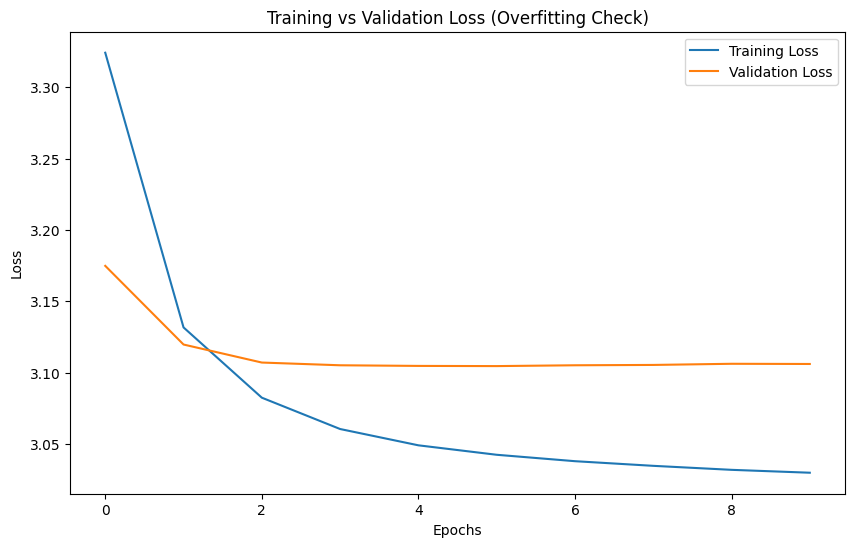


Top 5 words similar with king:
daughter: 0.6854
told: 0.6512
queen: 0.6409
kingdom: 0.6326
sent: 0.6284

Top 5 words similar with cat:
puss: 0.6083
tail: 0.5953
mouse: 0.5949
mewed: 0.5870
butcher: 0.5681

Top 5 results for king - man + woman:
hated: 0.5758
queen: 0.5699
told: 0.5648
happily: 0.5407
promised: 0.5263

Top 5 results for father - man + woman:
child: 0.6762
wept: 0.5901
glad: 0.5612
dear: 0.5587
wishing: 0.5474

Top 5 results for brother - man + woman:
brethren: 0.5729
sister: 0.5658
frightening: 0.5440
dear: 0.5173
lives: 0.5079

Top 5 results for cats - cat + mouse:
crape: 0.5482
bronze: 0.5278
drifted: 0.5133
tatty: 0.5038
goblins: 0.4991


In [3]:
### BASE CORPUS
# 
# Configuration
EMB_DIM = 50
EPOCHS = 50
WINDOW = 20
MIN_COUNT = 5
CORPUS_TYPE = 'corpus_base'

engine_base = Word2VecEngine(embedding_dim=EMB_DIM)
corpus_base,counts_base = engine_base.prepare_data(CORPUS_TYPE, MIN_COUNT,threshold=1e-3)
neg_table_base = engine_base.create_negative_table(counts_base)

model_base = Word2VecSGNS(len(engine_base.word2idx), EMB_DIM)

# --- START TRAINING ---
epoch_loss_base_train, epoch_loss_base_val = engine_base.train(CORPUS_TYPE, model_base, corpus_base,neg_table_base, window_size=WINDOW, epochs=EPOCHS,)
#plotting the loss curve
plt.figure(figsize=(10, 6))
plt.plot(epoch_loss_base_train, label='Training Loss')
plt.plot(epoch_loss_base_val, label='Validation Loss')
plt.title('Training vs Validation Loss (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

engine_base.find_similar_words(model_base,word="king",top_n=5)
engine_base.find_similar_words(model_base,word="cat",top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['king','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['father','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['brother','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['cats','mouse'], negative = ['cat'], top_n=5)


--- Loading and Cleaning: ./corpus_base/clean/corpus.txt ---
--- Generating Pairs ---
Total pairs: 6677880 | Train: 6010092 | Val: 667788
--- Trainning ---
Epoch 1/50 | Train Loss: 3.3580 | Val Loss: 3.2014
Epoch 2/50 | Train Loss: 3.1601 | Val Loss: 3.1413
Epoch 3/50 | Train Loss: 3.1151 | Val Loss: 3.1261
Epoch 4/50 | Train Loss: 3.0978 | Val Loss: 3.1226
Epoch 5/50 | Train Loss: 3.0900 | Val Loss: 3.1213
Epoch 6/50 | Train Loss: 3.0860 | Val Loss: 3.1205
Epoch 7/50 | Train Loss: 3.0832 | Val Loss: 3.1203
Epoch 8/50 | Train Loss: 3.0812 | Val Loss: 3.1201
Epoch 9/50 | Train Loss: 3.0795 | Val Loss: 3.1197
Epoch 10/50 | Train Loss: 3.0779 | Val Loss: 3.1193
Epoch 11/50 | Train Loss: 3.0763 | Val Loss: 3.1187
Epoch 12/50 | Train Loss: 3.0751 | Val Loss: 3.1186
Epoch 13/50 | Train Loss: 3.0737 | Val Loss: 3.1181
Epoch 14/50 | Train Loss: 3.0726 | Val Loss: 3.1180
Epoch 15/50 | Train Loss: 3.0714 | Val Loss: 3.1176
--> No improvement. Patience: 1/5
Epoch 16/50 | Train Loss: 3.0704 | Val 

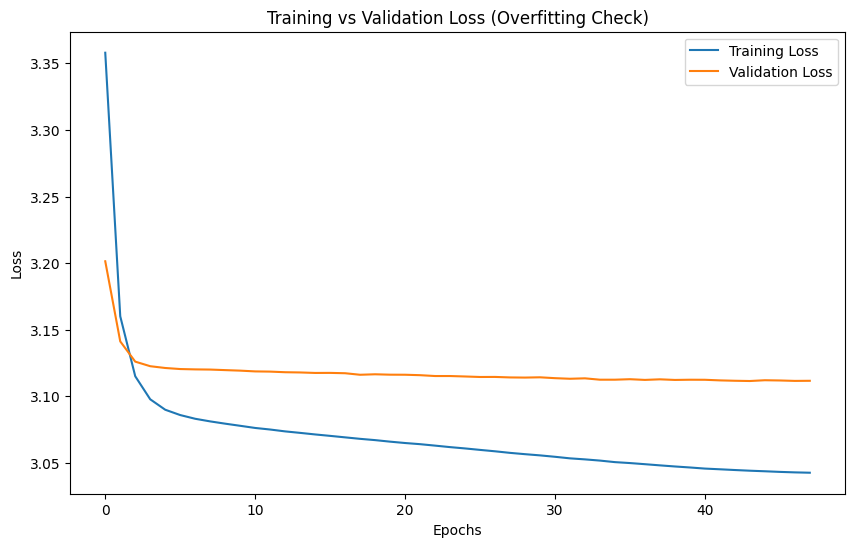


Top 5 words similar with king:
daughter: 0.7301
palace: 0.7184
begged: 0.7133
kingdom: 0.6984
princess: 0.6836

Top 5 words similar with cat:
mouse: 0.6723
puss: 0.6638
rat: 0.6462
mouser: 0.6377
mewed: 0.6240

Top 5 results for king - man + woman:
happily: 0.7361
queen: 0.6936
glad: 0.6163
princess: 0.6050
sorry: 0.5944

Top 5 results for father - man + woman:
mother: 0.7544
wept: 0.6677
child: 0.6628
dear: 0.6537
glad: 0.6383

Top 5 results for brother - man + woman:
frightening: 0.6170
seek: 0.6074
brethren: 0.6043
mother: 0.6027
merlin: 0.5987

Top 5 results for cats - cat + mouse:
scarlet: 0.6433
mouse-king: 0.6269
throats: 0.6224
darted: 0.6083
claws: 0.6037


In [4]:
### BASE CORPUS
# 
# Configuration
EMB_DIM = 30
EPOCHS = 50
WINDOW = 20
MIN_COUNT = 5
CORPUS_TYPE = 'corpus_base'

engine_base = Word2VecEngine(embedding_dim=EMB_DIM)
corpus_base,counts_base = engine_base.prepare_data(CORPUS_TYPE, MIN_COUNT,threshold=1e-3)
neg_table_base = engine_base.create_negative_table(counts_base)

model_base = Word2VecSGNS(len(engine_base.word2idx), EMB_DIM)

# --- START TRAINING ---
epoch_loss_base_train, epoch_loss_base_val = engine_base.train(CORPUS_TYPE, model_base, corpus_base,neg_table_base, window_size=WINDOW, epochs=EPOCHS,)
#plotting the loss curve
plt.figure(figsize=(10, 6))
plt.plot(epoch_loss_base_train, label='Training Loss')
plt.plot(epoch_loss_base_val, label='Validation Loss')
plt.title('Training vs Validation Loss (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

engine_base.find_similar_words(model_base,word="king",top_n=5)
engine_base.find_similar_words(model_base,word="cat",top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['king','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['father','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['brother','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['cats','mouse'], negative = ['cat'], top_n=5)


--- Loading and Cleaning: ./corpus_base/clean/corpus.txt ---
--- Generating Pairs ---
Total pairs: 4747300 | Train: 4272570 | Val: 474730
--- Trainning ---
Epoch 1/50 | Train Loss: 3.4391 | Val Loss: 3.2339
Epoch 2/50 | Train Loss: 3.1692 | Val Loss: 3.1248
Epoch 3/50 | Train Loss: 3.0896 | Val Loss: 3.0956
Epoch 4/50 | Train Loss: 3.0585 | Val Loss: 3.0870
Epoch 5/50 | Train Loss: 3.0446 | Val Loss: 3.0842
Epoch 6/50 | Train Loss: 3.0371 | Val Loss: 3.0828
Epoch 7/50 | Train Loss: 3.0326 | Val Loss: 3.0826
Epoch 8/50 | Train Loss: 3.0293 | Val Loss: 3.0821
Epoch 9/50 | Train Loss: 3.0271 | Val Loss: 3.0818
Epoch 10/50 | Train Loss: 3.0248 | Val Loss: 3.0817
Epoch 11/50 | Train Loss: 3.0232 | Val Loss: 3.0800
Epoch 12/50 | Train Loss: 3.0213 | Val Loss: 3.0797
Epoch 13/50 | Train Loss: 3.0194 | Val Loss: 3.0791
Epoch 14/50 | Train Loss: 3.0177 | Val Loss: 3.0786
Epoch 15/50 | Train Loss: 3.0158 | Val Loss: 3.0781
Epoch 16/50 | Train Loss: 3.0141 | Val Loss: 3.0771
Epoch 17/50 | Train L

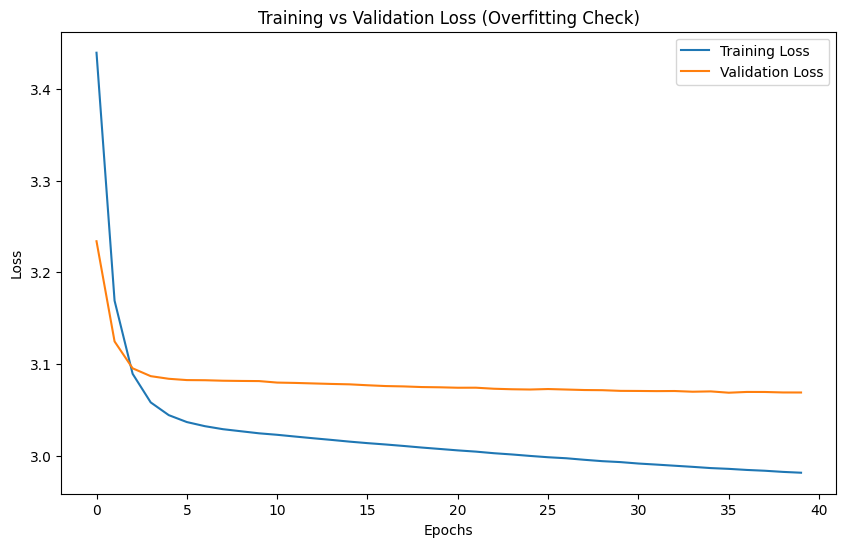


Top 5 words similar with king:
kingdom: 0.7943
begged: 0.7588
daughter: 0.7214
celebrated: 0.7172
1: 0.7070

Top 5 words similar with cat:
puss: 0.6820
started: 0.6756
game: 0.6644
hide: 0.6561
treat: 0.6518

Top 5 results for king - man + woman:
happily: 0.7268
queen: 0.6861
sorry: 0.6855
begged: 0.6581
seek: 0.6568

Top 5 results for father - man + woman:
mother: 0.7684
home: 0.7046
dear: 0.6630
back: 0.6608
kindly: 0.6546

Top 5 results for brother - man + woman:
seek: 0.7077
mother: 0.6736
back: 0.6729
bidding: 0.6697
bade: 0.6575

Top 5 results for cats - cat + mouse:
mice: 0.6872
mouse-king: 0.6379
fireworks: 0.6312
devoured: 0.6146
throats: 0.6118


In [5]:
### BASE CORPUS
# 
# Configuration
EMB_DIM = 30
EPOCHS = 50
WINDOW = 20
MIN_COUNT = 5
CORPUS_TYPE = 'corpus_base'

engine_base = Word2VecEngine(embedding_dim=EMB_DIM)
corpus_base,counts_base = engine_base.prepare_data(CORPUS_TYPE, MIN_COUNT,threshold=1e-4)
neg_table_base = engine_base.create_negative_table(counts_base)

model_base = Word2VecSGNS(len(engine_base.word2idx), EMB_DIM)

# --- START TRAINING ---
epoch_loss_base_train, epoch_loss_base_val = engine_base.train(CORPUS_TYPE, model_base, corpus_base,neg_table_base, window_size=WINDOW, epochs=EPOCHS,)
#plotting the loss curve
plt.figure(figsize=(10, 6))
plt.plot(epoch_loss_base_train, label='Training Loss')
plt.plot(epoch_loss_base_val, label='Validation Loss')
plt.title('Training vs Validation Loss (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

engine_base.find_similar_words(model_base,word="king",top_n=5)
engine_base.find_similar_words(model_base,word="cat",top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['king','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['father','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['brother','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['cats','mouse'], negative = ['cat'], top_n=5)


--- Loading and Cleaning: ./corpus_base/clean/corpus.txt ---
--- Generating Pairs ---
Total pairs: 4747940 | Train: 4273146 | Val: 474794
--- Trainning ---
Epoch 1/50 | Train Loss: 3.4552 | Val Loss: 3.2490
Epoch 2/50 | Train Loss: 3.1828 | Val Loss: 3.1384
Epoch 3/50 | Train Loss: 3.1046 | Val Loss: 3.1097
Epoch 4/50 | Train Loss: 3.0755 | Val Loss: 3.1005
Epoch 5/50 | Train Loss: 3.0628 | Val Loss: 3.0975
Epoch 6/50 | Train Loss: 3.0561 | Val Loss: 3.0957
Epoch 7/50 | Train Loss: 3.0518 | Val Loss: 3.0949
Epoch 8/50 | Train Loss: 3.0492 | Val Loss: 3.0936
--> No improvement. Patience: 1/5
Epoch 9/50 | Train Loss: 3.0474 | Val Loss: 3.0940
Epoch 10/50 | Train Loss: 3.0456 | Val Loss: 3.0936
Epoch 11/50 | Train Loss: 3.0442 | Val Loss: 3.0932
Epoch 12/50 | Train Loss: 3.0427 | Val Loss: 3.0919
Epoch 13/50 | Train Loss: 3.0411 | Val Loss: 3.0915
--> No improvement. Patience: 1/5
Epoch 14/50 | Train Loss: 3.0399 | Val Loss: 3.0915
Epoch 15/50 | Train Loss: 3.0387 | Val Loss: 3.0909
Epoch

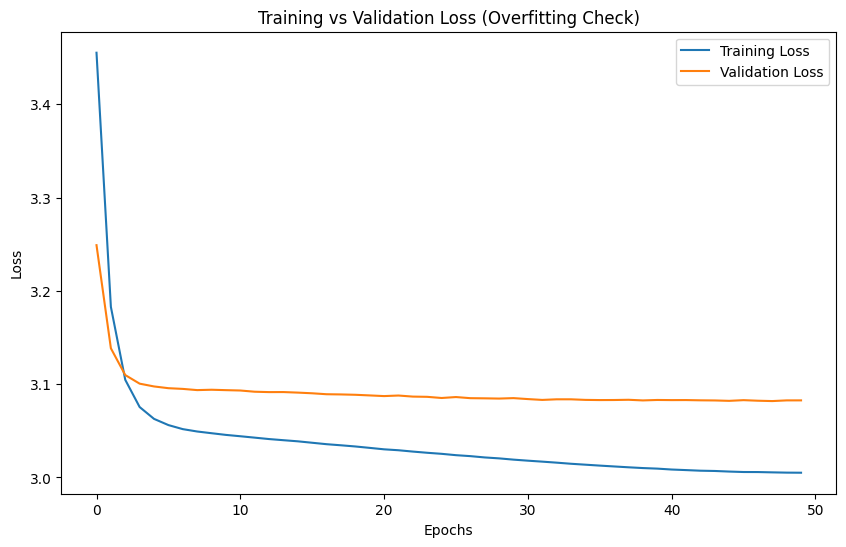


Top 5 words similar with king:
beg: 0.7416
begged: 0.7393
third: 0.7103
castle: 0.7061
ordered: 0.7019

Top 5 words similar with cat:
rat: 0.7732
puss: 0.7342
making: 0.7221
mouse: 0.7217
game: 0.7074

Top 5 results for king - man + woman:
faithfully: 0.7164
third: 0.7095
happily: 0.6996
glad: 0.6894
bidden: 0.6690

Top 5 results for father - man + woman:
mother: 0.7879
grieved: 0.7762
faithfully: 0.7659
promised: 0.7215
early: 0.7092

Top 5 results for brother - man + woman:
faithfully: 0.7941
bade: 0.7474
find: 0.7433
promised: 0.7162
grieved: 0.7114

Top 5 results for cats - cat + mouse:
mice: 0.7072
muslin: 0.6832
diamonds: 0.6473
crystal: 0.6442
fits: 0.6367


In [6]:
### BASE CORPUS
# 
# Configuration
EMB_DIM = 25
EPOCHS = 50
WINDOW = 20
MIN_COUNT = 5
CORPUS_TYPE = 'corpus_base'

engine_base = Word2VecEngine(embedding_dim=EMB_DIM)
corpus_base,counts_base = engine_base.prepare_data(CORPUS_TYPE, MIN_COUNT,threshold=1e-4)
neg_table_base = engine_base.create_negative_table(counts_base)

model_base = Word2VecSGNS(len(engine_base.word2idx), EMB_DIM)

# --- START TRAINING ---
epoch_loss_base_train, epoch_loss_base_val = engine_base.train(CORPUS_TYPE, model_base, corpus_base,neg_table_base, window_size=WINDOW, epochs=EPOCHS,)
#plotting the loss curve
plt.figure(figsize=(10, 6))
plt.plot(epoch_loss_base_train, label='Training Loss')
plt.plot(epoch_loss_base_val, label='Validation Loss')
plt.title('Training vs Validation Loss (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

engine_base.find_similar_words(model_base,word="king",top_n=5)
engine_base.find_similar_words(model_base,word="cat",top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['king','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['father','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['brother','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['cats','mouse'], negative = ['cat'], top_n=5)


--- Loading and Cleaning: ./corpus_base/clean/corpus.txt ---
--- Generating Pairs ---
Total pairs: 3559905 | Train: 3203914 | Val: 355991
--- Trainning ---
Epoch 1/50 | Train Loss: 3.5165 | Val Loss: 3.2749
Epoch 2/50 | Train Loss: 3.2194 | Val Loss: 3.1632
Epoch 3/50 | Train Loss: 3.1229 | Val Loss: 3.1152
Epoch 4/50 | Train Loss: 3.0768 | Val Loss: 3.1004
Epoch 5/50 | Train Loss: 3.0552 | Val Loss: 3.0942
Epoch 6/50 | Train Loss: 3.0435 | Val Loss: 3.0932
Epoch 7/50 | Train Loss: 3.0362 | Val Loss: 3.0926
Epoch 8/50 | Train Loss: 3.0318 | Val Loss: 3.0913
--> No improvement. Patience: 1/5
Epoch 9/50 | Train Loss: 3.0283 | Val Loss: 3.0921
--> No improvement. Patience: 2/5
Epoch 10/50 | Train Loss: 3.0257 | Val Loss: 3.0915
Epoch 11/50 | Train Loss: 3.0232 | Val Loss: 3.0906
--> No improvement. Patience: 1/5
Epoch 12/50 | Train Loss: 3.0217 | Val Loss: 3.0918
--> No improvement. Patience: 2/5
Epoch 13/50 | Train Loss: 3.0200 | Val Loss: 3.0910
--> No improvement. Patience: 3/5
Epoch 1

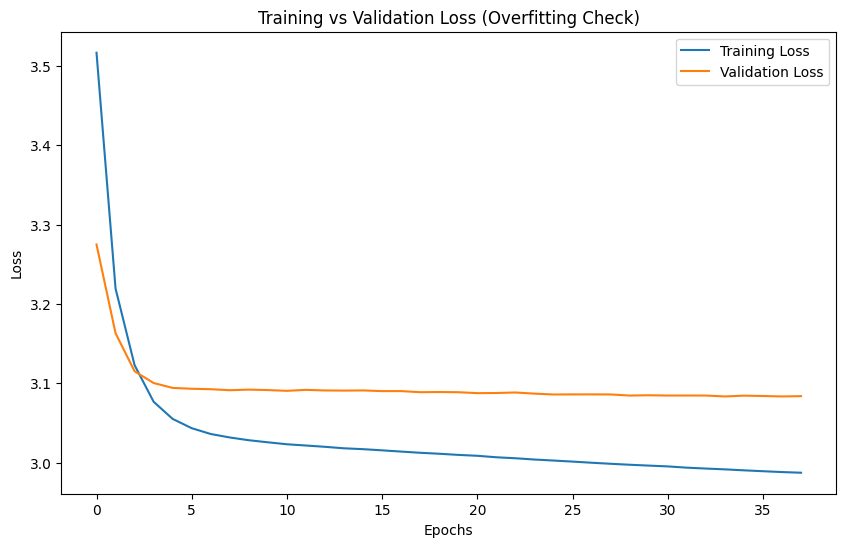


Top 5 words similar with king:
counsel: 0.7614
ordered: 0.7459
waiting: 0.7314
court: 0.7170
feast: 0.7167

Top 5 words similar with cat:
puss: 0.7938
rat: 0.7896
treat: 0.7533
rats: 0.7371
miss: 0.7301

Top 5 results for king - man + woman:
sister: 0.8058
waiting: 0.7250
dear: 0.7178
counsel: 0.6988
happily: 0.6859

Top 5 results for father - man + woman:
sister: 0.7815
dear: 0.7807
mother: 0.7694
loved: 0.7276
troubled: 0.7258

Top 5 results for brother - man + woman:
awhile: 0.7600
sister: 0.7590
wishing: 0.7368
travels: 0.7222
mother: 0.7120

Top 5 results for cats - cat + mouse:
devoured: 0.7106
darkened: 0.7084
mouse-king: 0.6992
revealed: 0.6897
turtle-doves: 0.6563


In [7]:
### BASE CORPUS
# 
# Configuration
EMB_DIM = 25
EPOCHS = 50
WINDOW = 15
MIN_COUNT = 5
CORPUS_TYPE = 'corpus_base'

engine_base = Word2VecEngine(embedding_dim=EMB_DIM)
corpus_base,counts_base = engine_base.prepare_data(CORPUS_TYPE, MIN_COUNT,threshold=1e-4)
neg_table_base = engine_base.create_negative_table(counts_base)

model_base = Word2VecSGNS(len(engine_base.word2idx), EMB_DIM)

# --- START TRAINING ---
epoch_loss_base_train, epoch_loss_base_val = engine_base.train(CORPUS_TYPE, model_base, corpus_base,neg_table_base, window_size=WINDOW, epochs=EPOCHS,)
#plotting the loss curve
plt.figure(figsize=(10, 6))
plt.plot(epoch_loss_base_train, label='Training Loss')
plt.plot(epoch_loss_base_val, label='Validation Loss')
plt.title('Training vs Validation Loss (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

engine_base.find_similar_words(model_base,word="king",top_n=5)
engine_base.find_similar_words(model_base,word="cat",top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['king','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['father','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['brother','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['cats','mouse'], negative = ['cat'], top_n=5)


--- Loading and Cleaning: ./corpus_base/clean/corpus.txt ---
--- Generating Pairs ---
Total pairs: 2368380 | Train: 2131542 | Val: 236838
--- Trainning ---
Epoch 1/50 | Train Loss: 3.6002 | Val Loss: 3.3087
Epoch 2/50 | Train Loss: 3.2707 | Val Loss: 3.2138
Epoch 3/50 | Train Loss: 3.1598 | Val Loss: 3.1360
Epoch 4/50 | Train Loss: 3.0794 | Val Loss: 3.1029
Epoch 5/50 | Train Loss: 3.0320 | Val Loss: 3.0915
Epoch 6/50 | Train Loss: 3.0039 | Val Loss: 3.0867
Epoch 7/50 | Train Loss: 2.9869 | Val Loss: 3.0861
--> No improvement. Patience: 1/5
Epoch 8/50 | Train Loss: 2.9753 | Val Loss: 3.0862
--> No improvement. Patience: 2/5
Epoch 9/50 | Train Loss: 2.9670 | Val Loss: 3.0887
--> No improvement. Patience: 3/5
Epoch 10/50 | Train Loss: 2.9607 | Val Loss: 3.0889
--> No improvement. Patience: 4/5
Epoch 11/50 | Train Loss: 2.9557 | Val Loss: 3.0903
--> No improvement. Patience: 5/5
!!! Early Stopping triggered at epoch 12 !!!


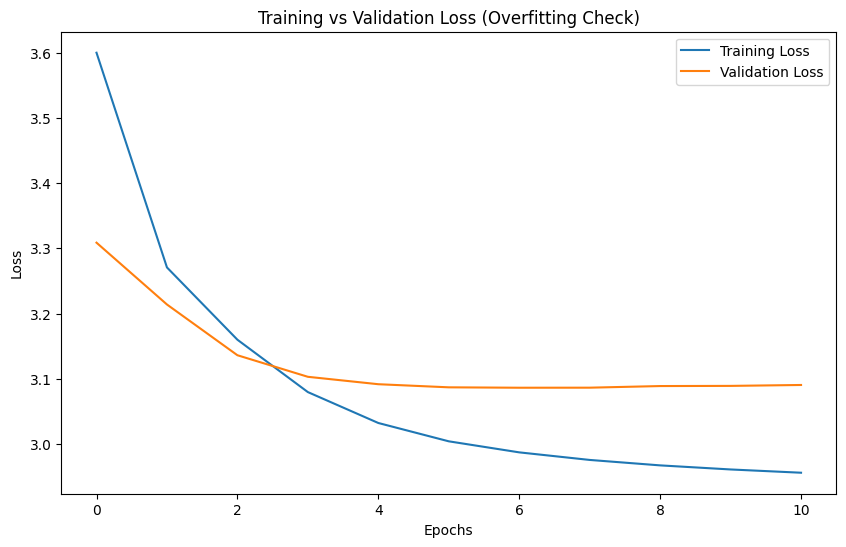


Top 5 words similar with king:
wedding: 0.6801
proper: 0.6758
kingdom: 0.6736
brothers: 0.6732
courtesy: 0.6703

Top 5 words similar with cat:
puss: 0.7650
mouse: 0.7134
rat: 0.6952
hay: 0.6890
gnaw: 0.6660

Top 5 results for king - man + woman:
waiting: 0.7789
brothers: 0.6999
expecting: 0.6879
spinning-wheels: 0.6432
sister: 0.6322

Top 5 results for father - man + woman:
dearest: 0.7319
waiting: 0.6993
keep: 0.6704
sister: 0.6623
comforted: 0.6578

Top 5 results for brother - man + woman:
keep: 0.7686
girt: 0.7415
sister: 0.6914
merlin: 0.6763
promised: 0.6623

Top 5 results for cats - cat + mouse:
hideous: 0.6456
skewer: 0.6438
sausage: 0.6287
touched: 0.6281
lifted: 0.6229


In [8]:
### BASE CORPUS
# 
# Configuration
EMB_DIM = 30
EPOCHS = 50
WINDOW = 10
MIN_COUNT = 5
CORPUS_TYPE = 'corpus_base'

engine_base = Word2VecEngine(embedding_dim=EMB_DIM)
corpus_base,counts_base = engine_base.prepare_data(CORPUS_TYPE, MIN_COUNT,threshold=1e-4)
neg_table_base = engine_base.create_negative_table(counts_base)

model_base = Word2VecSGNS(len(engine_base.word2idx), EMB_DIM)

# --- START TRAINING ---
epoch_loss_base_train, epoch_loss_base_val = engine_base.train(CORPUS_TYPE, model_base, corpus_base,neg_table_base, window_size=WINDOW, epochs=EPOCHS,)
#plotting the loss curve
plt.figure(figsize=(10, 6))
plt.plot(epoch_loss_base_train, label='Training Loss')
plt.plot(epoch_loss_base_val, label='Validation Loss')
plt.title('Training vs Validation Loss (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

engine_base.find_similar_words(model_base,word="king",top_n=5)
engine_base.find_similar_words(model_base,word="cat",top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['king','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['father','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['brother','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['cats','mouse'], negative = ['cat'], top_n=5)


--- Loading and Cleaning: ./corpus_base/clean/corpus.txt ---
--- Generating Pairs ---
Total pairs: 1671690 | Train: 1504521 | Val: 167169
--- Trainning ---
Epoch 1/50 | Train Loss: 3.7532 | Val Loss: 3.3324
Epoch 2/50 | Train Loss: 3.3207 | Val Loss: 3.2813
Epoch 3/50 | Train Loss: 3.2062 | Val Loss: 3.1467
Epoch 4/50 | Train Loss: 3.0562 | Val Loss: 3.0596
Epoch 5/50 | Train Loss: 2.9512 | Val Loss: 3.0226
Epoch 6/50 | Train Loss: 2.8909 | Val Loss: 3.0090
Epoch 7/50 | Train Loss: 2.8551 | Val Loss: 3.0061
Epoch 8/50 | Train Loss: 2.8333 | Val Loss: 3.0036
--> No improvement. Patience: 1/5
Epoch 9/50 | Train Loss: 2.8189 | Val Loss: 3.0039
--> No improvement. Patience: 2/5
Epoch 10/50 | Train Loss: 2.8081 | Val Loss: 3.0042
--> No improvement. Patience: 3/5
Epoch 11/50 | Train Loss: 2.8001 | Val Loss: 3.0037
--> No improvement. Patience: 4/5
Epoch 12/50 | Train Loss: 2.7937 | Val Loss: 3.0048
--> No improvement. Patience: 5/5
!!! Early Stopping triggered at epoch 13 !!!


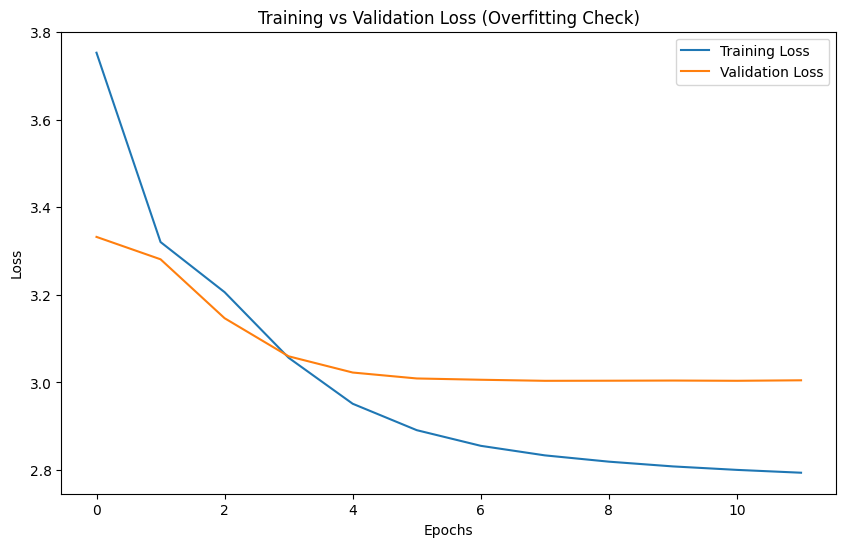


Top 5 words similar with king:
rode: 0.6944
fight: 0.6880
liquor: 0.6673
predestinate: 0.6636
armour: 0.6573

Top 5 words similar with cat:
mouse: 0.7180
tail: 0.6996
began: 0.6836
korbes: 0.6734
get: 0.6726

Top 5 results for king - man + woman:
hame: 0.6795
hindered: 0.6586
bows: 0.6492
grand: 0.6448
spinning-wheel: 0.6367

Top 5 results for father - man + woman:
teeny-tiny: 0.6990
village: 0.6694
engaged: 0.6510
bonnet: 0.6320
slice: 0.6191

Top 5 results for brother - man + woman:
bonnet: 0.6899
gang: 0.6719
teeny-tiny: 0.6472
friday: 0.6400
baron: 0.6356

Top 5 results for cats - cat + mouse:
beautifully: 0.6984
bearded: 0.6453
possible: 0.6276
shuddering: 0.6223
swam: 0.6206


In [9]:
### BASE CORPUS
# 
# Configuration
EMB_DIM = 30
EPOCHS = 50
WINDOW = 15
MIN_COUNT = 5
CORPUS_TYPE = 'corpus_base'

engine_base = Word2VecEngine(embedding_dim=EMB_DIM)
corpus_base,counts_base = engine_base.prepare_data(CORPUS_TYPE, MIN_COUNT,threshold=1e-5)
neg_table_base = engine_base.create_negative_table(counts_base)

model_base = Word2VecSGNS(len(engine_base.word2idx), EMB_DIM)

# --- START TRAINING ---
epoch_loss_base_train, epoch_loss_base_val = engine_base.train(CORPUS_TYPE, model_base, corpus_base,neg_table_base, window_size=WINDOW, epochs=EPOCHS,)
#plotting the loss curve
plt.figure(figsize=(10, 6))
plt.plot(epoch_loss_base_train, label='Training Loss')
plt.plot(epoch_loss_base_val, label='Validation Loss')
plt.title('Training vs Validation Loss (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

engine_base.find_similar_words(model_base,word="king",top_n=5)
engine_base.find_similar_words(model_base,word="cat",top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['king','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['father','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['brother','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['cats','mouse'], negative = ['cat'], top_n=5)


In [ ]:
### EXTENDED CORPUS
# 
# Configuration
EMB_DIM = 50
EPOCHS = 100
WINDOW = 20
MIN_COUNT = 15
CORPUS_TYPE = 'corpus_ext'

engine_ext = Word2VecEngine(embedding_dim=EMB_DIM)
corpus_ext,counts_base = engine_ext.prepare_data(CORPUS_TYPE, MIN_COUNT)
neg_table_ext = engine_ext.create_negative_table(counts_base)

model_ext = Word2VecSGNS(len(engine_ext.word2idx), EMB_DIM)

# --- START TRAINING ---
epoch_loss_base = engine_ext.train(CORPUS_TYPE, model_ext, corpus_ext,neg_table_ext, window_size=WINDOW, epochs=EPOCHS)


#plotting the loss curve
plt.plot(epoch_loss_base)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')


engine_ext.find_similar_words(model_ext,word="king",top_n=5)
engine_ext.find_similar_words(model_ext,word="cat",top_n=5)
engine_ext.find_similar_embedding(model_ext,positive = ['king','woman'], negative = ['man'], top_n=5)
engine_ext.find_similar_embedding(model_ext,positive = ['father','woman'], negative = ['man'], top_n=5)
engine_ext.find_similar_embedding(model_ext,positive = ['brother','woman'], negative = ['man'], top_n=5)
engine_ext.find_similar_embedding(model_ext,positive = ['cats','mouse'], negative = ['cat'], top_n=5)
